# <center>ASTR4004/8004 - Inference - Part 2</center> 

## Bayes' theorem:
$$
P(\theta|D)=P(D|\theta)\frac{P(\theta)}{P(D)}
$$

* $P(D|\theta)$: the likelihood function, representing the probability of observing the data ($D$) given a specific set of modeling parameters ($\theta$)
* $P(\theta)$: the prior probability distribution over the modeling parameters ($\theta$). This represents our initial beliefs of possible values of $\theta$
* $P(D)$: the marginal likelihood (Bayesian evidence), obtained by summing over discrete parameters or integrating over continuous ones: $P(D)=\int P(D|\theta)P(\theta)\,\mathrm{d}\theta$
* $P(\theta|D)$: the posterior probability distribution over the modeling parameters ($\theta$) given the data.

This notebook fits the distribution of a dataset within a Bayesian framework. The model considered here is a Normal distribution with its mean and standard deviation treated as free parameters.

## Useful packages

In [2]:
np.ravel?

Signature:       np.ravel(a, order='C')
Call signature:  np.ravel(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function ravel at 0x1101d9080>
File:            /opt/miniconda3/envs/astr4004/lib/python3.11/site-packages/numpy/_core/fromnumeric.py
Docstring:      
Return a contiguous flattened array.

A 1-D array, containing the elements of the input, is returned.  A copy is
made only if needed.

As of NumPy 1.10, the returned array will have the same type as the input
array. (for example, a masked array will be returned for a masked array
input)

Parameters
----------
a : array_like
    Input array.  The elements in `a` are read in the order specified by
    `order`, and packed as a 1-D array.
order : {'C','F', 'A', 'K'}, optional

    The elements of `a` are read using this index order. 'C' means
    to index the elements in row-major, C-style order,
    with the last axis index changing fastest, back to the first
    axis index changing slowest.  'F' mea

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

## Data (D) and the task
Given a dataset, our task is to infer the parameters of a suitable probability distribution.

Text(0, 0.5, 'PDF')

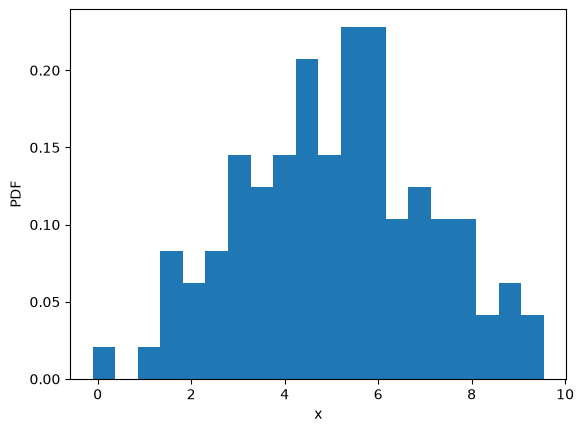

In [2]:
# Set seed for reproducibility
np.random.seed(0)

# Generate dataset (100 data points) following a normal distribution
mean_real, std_real = 5, 2
n_data = 100
data = np.random.normal(loc=mean_real, scale=std_real, size=n_data)
plt.hist(data, bins=20, density=True)
plt.xlabel('x')
plt.ylabel('PDF')

## Propose your model
* The histogram suggests that our dataset $D$ may follow a Normal distribution, so we adopt that as our model.
* Our parameter vector is $\theta=(\mu,\sigma)$: the mean (`mean`) and standard deviation (`std`).

## Let's write a generic function to sample from a 2D parameter space (x,y) based on any given `pdf(x,y)`

Inverse CDF sampling is primarily designed for generating samples from one-dimensional distributions. When it comes to high-dimensional distributions, it becomes more complex and often impractical to compute and invert the CDF, which is a multidimensional function.

In rejection sampling, we draw candidates from a proposal density $q(\theta)$ and choose a constant $M$ such that $p(\theta)\le Mq(\theta)$ everywhere. A candidate is accepted with probability $p(\theta)/(Mq(\theta))$. Here the proposal is uniform over a rectangular region, so this reduces to comparing the target density with a constant envelope `pdf_max`. The envelope must bound the target everywhere; underestimating it biases the sample.

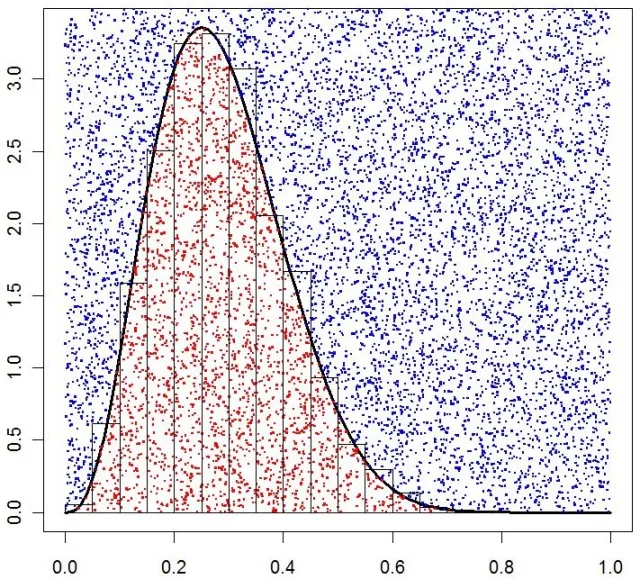

In [3]:
def sample_parameters(pdf, x_min, x_max, y_min, y_max, num_samples,
                      pdf_max=None, grid_size=150, max_draws=1_000_000):
    '''
    Sample a two-dimensional PDF using rejection sampling.

    Parameters:
    - pdf: a non-negative function of (x, y), proportional to the target PDF
    - x_min, x_max, y_min, y_max: rectangular sampling bounds
    - num_samples: the number of samples to generate
    - pdf_max: a known upper bound on the PDF; estimated on a grid if omitted

    Return:
    - x_samples, y_samples: samples following the given PDF
    - efficiency: the accepted fraction of proposals
    '''
    if pdf_max is None:
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size)
        grid_values = np.array([pdf(x, y) for x in x_grid for y in y_grid])
        if not np.all(np.isfinite(grid_values)) or np.any(grid_values < 0):
            raise ValueError('The PDF must be finite and non-negative.')
        pdf_max = 1.05 * grid_values.max()

    if not np.isfinite(pdf_max) or pdf_max <= 0:
        raise ValueError('pdf_max must be a positive finite envelope.')

    accepted_x, accepted_y = [], []
    draws = accepted_total = 0

    while len(accepted_x) < num_samples and draws < max_draws:
        remaining = num_samples - len(accepted_x)
        batch_size = min(max_draws - draws, max(1000, 2 * remaining))
        x_proposed = np.random.uniform(x_min, x_max, batch_size)
        y_proposed = np.random.uniform(y_min, y_max, batch_size)
        values = np.array([pdf(x, y) for x, y in zip(x_proposed, y_proposed)])

        if not np.all(np.isfinite(values)) or np.any(values < 0):
            raise ValueError('The PDF must be finite and non-negative.')
        if np.any(values > pdf_max):
            raise ValueError('The rejection envelope is too low; increase pdf_max.')

        accept = np.random.uniform(0, pdf_max, batch_size) < values
        accepted_total += accept.sum()
        accepted_x.extend(x_proposed[accept])
        accepted_y.extend(y_proposed[accept])
        draws += batch_size

    if len(accepted_x) < num_samples:
        raise RuntimeError('Maximum proposal count reached before enough samples were accepted.')

    efficiency = accepted_total / draws
    return (np.asarray(accepted_x[:num_samples]),
            np.asarray(accepted_y[:num_samples]), efficiency)

In [ ]:
np.ravel?

### uniform between $x\in[-1,1]$ and $y\in[-1,1]$

(-2.0, 2.0)

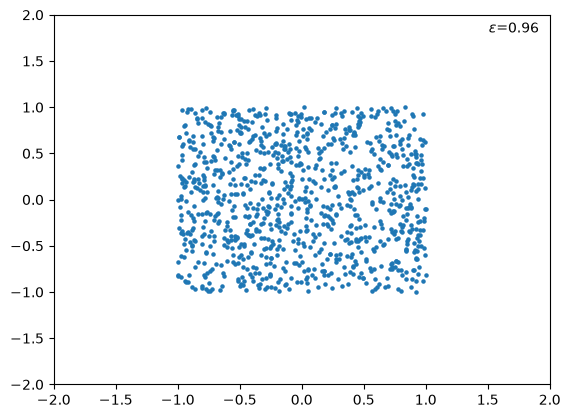

In [4]:
def pdf(x,y):
    if x<-1 or x>1 or y<-1 or y>1:
        return 0
    else:
        return 0.25
    
x_samples, y_samples, efficiency = sample_parameters(pdf, -1, 1, -1, 1, 1000)
plt.scatter(x_samples, y_samples, s=5)
plt.text(0.98, 0.98, r'$\epsilon$=%.2f'%efficiency, 
         va='top', ha='right', transform=plt.gca().transAxes)
plt.xlim(-2,2)
plt.ylim(-2,2)

### uniform within the circle of $x^2+y^2<1$

(-1.0, 1.0)

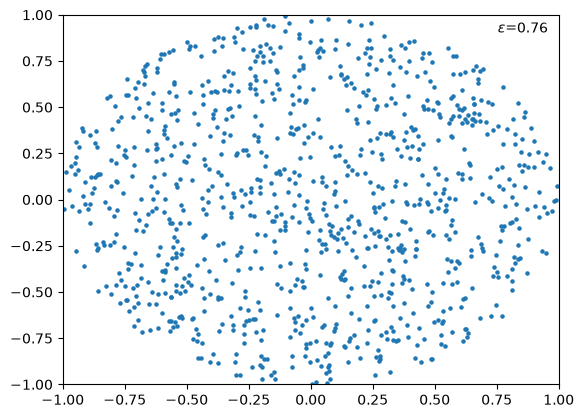

In [5]:
def pdf(x,y):
    if x**2+y**2>1:
        return 0
    else:
        return 1/np.pi
    
x_samples, y_samples, efficiency = sample_parameters(pdf, -1, 1, -1, 1, 1000)
plt.scatter(x_samples, y_samples, s=5)
plt.text(0.98, 0.98, r'$\epsilon$=%.2f'%efficiency, 
         va='top', ha='right', transform=plt.gca().transAxes)
plt.xlim(-1,1)
plt.ylim(-1,1)

## 2D Normal distribution

(-5.0, 5.0)

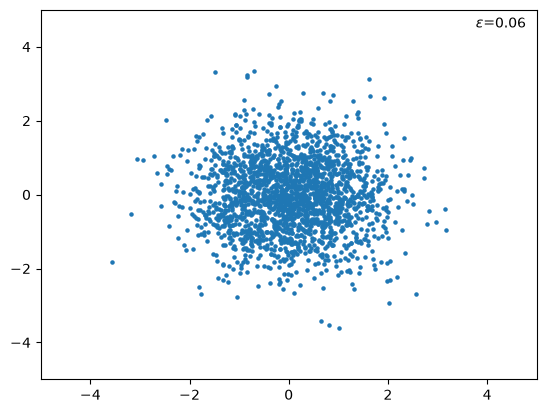

In [6]:
def norm_pdf(x, mean, std):
    return np.exp(-((x - mean) / std)**2 / 2) / (std * np.sqrt(2 * np.pi))

def pdf(x,y):
    return norm_pdf(x,0,1)*norm_pdf(y,0,1)
    
x_samples, y_samples, efficiency = sample_parameters(pdf, -5, 5, -5, 5, 2000)
plt.scatter(x_samples, y_samples, s=5)
plt.text(0.98, 0.98, r'$\epsilon$=%.2f'%efficiency, 
         va='top', ha='right', transform=plt.gca().transAxes)
plt.xlim(-5,5)
plt.ylim(-5,5)

<font color='red'>Rejection sampling becomes inefficient for sharply peaked targets and in higher dimensions: most of the proposal-envelope volume can lie where the target density is negligible.</font>

## Define the prior of your model parameters

In [7]:
mean_min, mean_max = 4, 6
std_min, std_max   = 1, 3

# A uniform prior within the stated bounds and zero outside them
def initial_prior(mean, std):
    if mean_min <= mean <= mean_max and std_min <= std <= std_max:
        return 1.0 / ((mean_max - mean_min) * (std_max - std_min))
    return 0.0

## Calculate the likelihood

For independent observations $D=\{x_i\}_{i=1}^{N}$, the joint likelihood is the product of their Normal densities:
$$
P(D|\mu,\sigma)=\prod_{i=1}^{N}\frac{1}{\sqrt{2\pi}\sigma}
\exp\left[-\frac{1}{2}\left(\frac{x_i-\mu}{\sigma}\right)^2\right].
$$
In code, we sum the logarithms of these factors for numerical stability.

In [8]:
def likelihood(x, mean, std):
    return norm_pdf(x, mean, std)

def log_likelihood(x, mean, std):
    residual = (x - mean) / std
    return np.sum(-0.5 * residual**2 - np.log(std * np.sqrt(2 * np.pi)))

## Bayesian inference

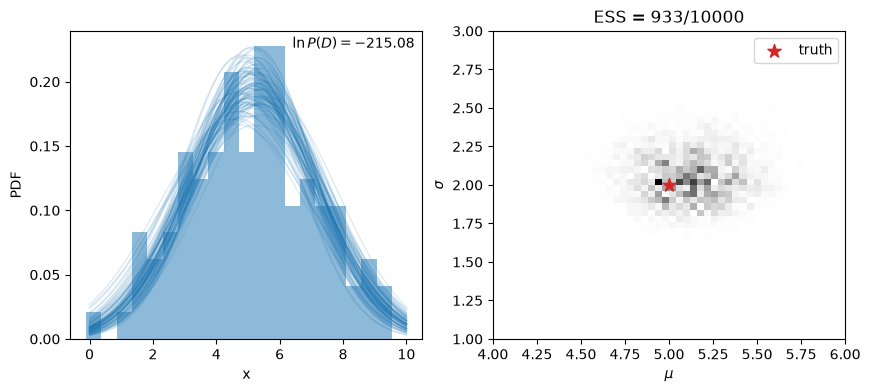

In [9]:
num_particles = 10000
xs = np.linspace(0, 10, 200)

# Draw particles from the prior. Sampling from the prior already includes
# the prior factor in Bayes' rule.
mean_prior, std_prior, _ = sample_parameters(
    initial_prior, mean_min, mean_max, std_min, std_max, num_particles,
    pdf_max=initial_prior((mean_min + mean_max) / 2,
                          (std_min + std_max) / 2)
)
prior_particles = np.column_stack((mean_prior, std_prior))

# Evaluate the full-data log-likelihood for every prior particle.
log_likelihood_samples = np.array([
    log_likelihood(data, mean, std) for mean, std in prior_particles
])

# Estimate P(D) by Monte Carlo and normalize the importance weights.
log_normalization = logsumexp(log_likelihood_samples)
log_evidence = log_normalization - np.log(num_particles)
log_weights = log_likelihood_samples - log_normalization
posterior_weights = np.exp(log_weights)
effective_sample_size = 1.0 / np.sum(posterior_weights**2)

# Resample joint particles: one index preserves the mean--std correlation.
resampled_indices = np.random.choice(
    num_particles, size=num_particles, replace=True, p=posterior_weights
)
posterior_particles = prior_particles[resampled_indices]

# Plot the data and model curves drawn from the posterior.
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].hist(data, bins=20, alpha=0.5, density=True, label='data')
for mean, std in posterior_particles[np.random.choice(num_particles, 100)]:
    axs[0].plot(xs, norm_pdf(xs, mean, std),
                lw=1, alpha=0.15, color='tab:blue')
axs[0].set_xlabel('x')
axs[0].set_ylabel('PDF')
axs[0].text(0.98, 0.98, rf'$\ln P(D)={log_evidence:.2f}$',
            ha='right', va='top', transform=axs[0].transAxes)

# Plot the joint posterior.
axs[1].hist2d(posterior_particles[:, 0], posterior_particles[:, 1],
              range=((mean_min, mean_max), (std_min, std_max)),
              bins=50, density=True, cmap='Greys')
axs[1].scatter(mean_real, std_real, marker='*', color='tab:red',
               s=100, label='truth')
axs[1].set_xlabel(r'$\mu$')
axs[1].set_ylabel(r'$\sigma$')
axs[1].set_title(f'ESS = {effective_sample_size:.0f}/{num_particles}')
axs[1].legend();

<font color='red'>Importance sampling can become inefficient when the posterior occupies only a small part of the prior volume. The effective sample size (ESS) quantifies this weight degeneracy: a small ESS means that only a few particles carry most of the posterior probability.</font>

### Diagnose importance-weight degeneracy

Effective sample size: 932.9 / 10000
Unique particles after resampling: 1738 / 10000


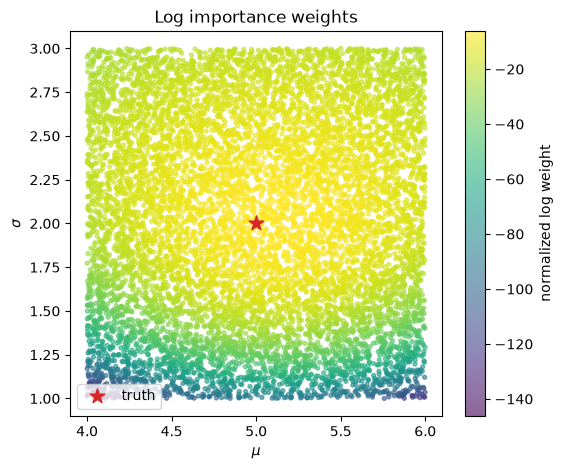

In [10]:
unique_particles = np.unique(resampled_indices).size
print(f'Effective sample size: {effective_sample_size:.1f} / {num_particles}')
print(f'Unique particles after resampling: {unique_particles} / {num_particles}')

# Colour prior particles by their normalized log importance weight.
fig, ax = plt.subplots(figsize=(6, 5))
points = ax.scatter(prior_particles[:, 0], prior_particles[:, 1],
                    c=log_weights, s=8, alpha=0.6, cmap='viridis')
ax.scatter(mean_real, std_real, marker='*', color='tab:red',
           s=120, label='truth')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\sigma$')
ax.set_title('Log importance weights')
ax.legend()
fig.colorbar(points, ax=ax, label='normalized log weight');

<font color='red'>Resampling creates an equally weighted posterior sample, but it creates no new information. Repeated particles are a symptom of a small ESS, and resampling mean and standard deviation independently would incorrectly destroy their posterior correlation.</font>

### Metropolis–Hastings algorithm

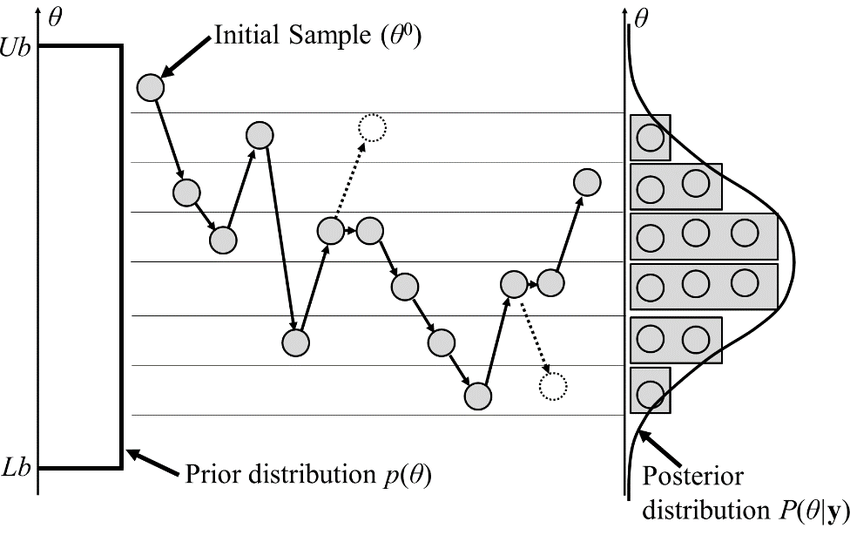

For a symmetric random-walk proposal, one Metropolis step is:

1. Start from the current state $\theta$.
2. Propose a nearby state $\theta^{\prime}$.
3. Accept it when $\log u < \min[0, \log p(\theta^{\prime}|D)-\log p(\theta|D)]$, where $u\sim\mathcal{U}(0,1)$. Otherwise, repeat the current state.

The log form avoids numerical underflow. An asymmetric proposal also requires the Hastings proposal-density ratio.

In [11]:
def log_prior(params):
    mean, std = params
    prior_density = initial_prior(mean, std)
    if prior_density <= 0:
        return -np.inf
    return np.log(prior_density)

def log_posterior(params, x):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(x, *params)

def metropolis_hastings(log_pdf, initial_state, num_steps, proposal_scale):
    '''Sample one Markov chain using a symmetric Gaussian proposal.

    Returns the chain, its log probabilities, and the acceptance fraction.
    '''
    current = np.asarray(initial_state, dtype=float).copy()
    proposal_scale = np.broadcast_to(proposal_scale, current.shape)
    chain = np.empty((num_steps, current.size))
    log_probabilities = np.empty(num_steps)
    current_log_probability = log_pdf(current)
    if not np.isfinite(current_log_probability):
        raise ValueError('initial_state must have finite log probability')

    accepted = 0
    for step in range(num_steps):
        proposal = current + np.random.normal(scale=proposal_scale)
        proposal_log_probability = log_pdf(proposal)
        log_acceptance_ratio = proposal_log_probability - current_log_probability

        if np.log(np.random.rand()) < min(0.0, log_acceptance_ratio):
            current = proposal
            current_log_probability = proposal_log_probability
            accepted += 1

        chain[step] = current
        log_probabilities[step] = current_log_probability

    return chain, log_probabilities, accepted / num_steps

<font color='red'>Discard the early burn-in portion before summarizing a chain, and inspect trace plots and multiple chains for convergence. Proposal scales that are too small mix slowly; scales that are too large reject too often. MCMC targets the posterior but does not, by itself, provide the evidence $P(D)$.</font>

## Markov chain Monte Carlo

* **Monte Carlo:** use random samples to approximate expectations.
* **Markov:** conditional on the current state, the next state is independent of earlier states: $P(S_{n+1}|S_n,S_{n-1},\ldots)=P(S_{n+1}|S_n)$.
* **Chain:** the resulting ordered sequence of correlated samples.

After burn-in, a well-mixed chain spends time in each region in proportion to its posterior probability.

Mean acceptance fraction: 0.469
Posterior mean: [5.11483623 2.05297662]


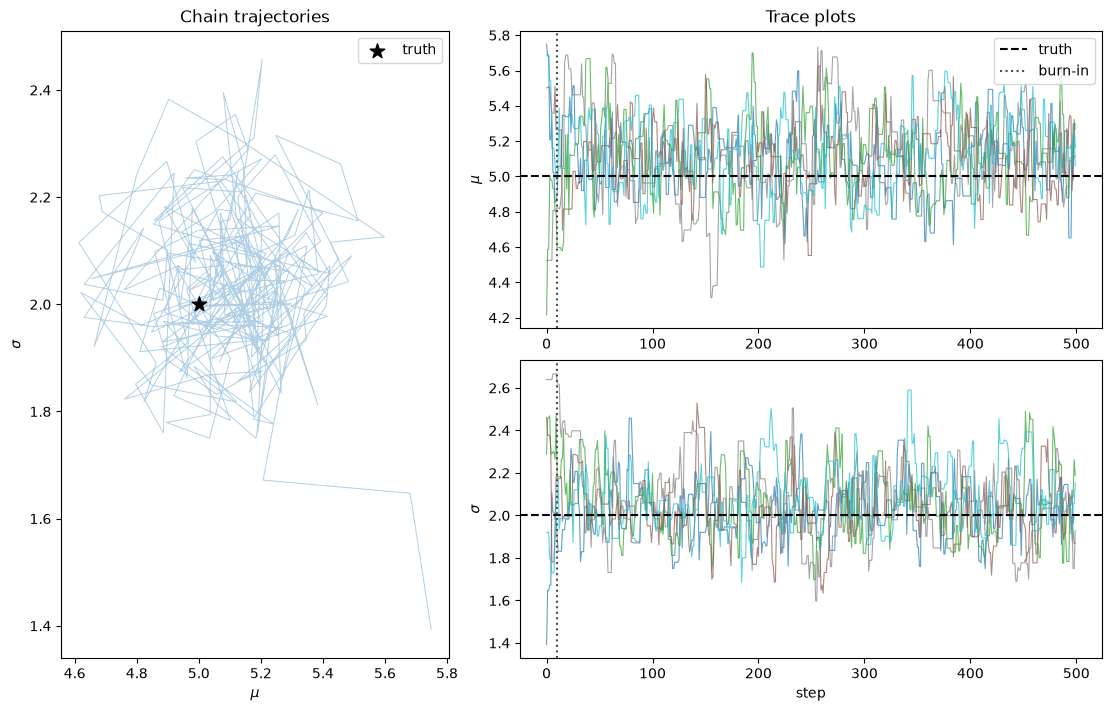

In [16]:
n_chains = 5
n_steps = 500
burn_in = 10
proposal_scale = np.array([0.25, 0.18])
mean_initial, std_initial, _ = sample_parameters(
    initial_prior, mean_min, mean_max, std_min, std_max, n_chains,
    pdf_max=initial_prior((mean_min + mean_max) / 2,
                          (std_min + std_max) / 2)
)
initial_states = np.column_stack((mean_initial, std_initial))

chains = np.empty((n_chains, n_steps, 2))
chain_log_probabilities = np.empty((n_chains, n_steps))
acceptance_fractions = np.empty(n_chains)
for i, initial in enumerate(initial_states):
    chains[i], chain_log_probabilities[i], acceptance_fractions[i] = (
        metropolis_hastings(
            lambda params: log_posterior(params, data),
            initial, n_steps, proposal_scale
        )
    )

post_burn_in_chains = chains[:, burn_in:]
flat_samples = post_burn_in_chains.reshape(-1, 2)
print(f'Mean acceptance fraction: {acceptance_fractions.mean():.3f}')
print('Posterior mean:', flat_samples.mean(axis=0))

colors = plt.cm.tab10(np.linspace(0, 1, n_chains))
fig = plt.figure(figsize=(11, 7), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=(1.0, 1.5))
ax_joint = fig.add_subplot(grid[:, 0])
ax_mean = fig.add_subplot(grid[0, 1])
ax_std = fig.add_subplot(grid[1, 1], sharex=ax_mean)

for i, color in enumerate(colors):
    if i == 0 :
        ax_joint.plot(chains[i, :, 0], chains[i, :, 1],
                    lw=0.7, alpha=0.35, color=color)
    ax_mean.plot(chains[i, :, 0], lw=0.8, alpha=0.7, color=color)
    ax_std.plot(chains[i, :, 1], lw=0.8, alpha=0.7, color=color)

ax_joint.scatter(mean_real, std_real, marker='*', color='black',
                 s=120, zorder=3, label='truth')
ax_joint.set_xlabel(r'$\mu$')
ax_joint.set_ylabel(r'$\sigma$')
ax_joint.set_title('Chain trajectories')
ax_joint.legend()

ax_mean.axhline(mean_real, color='black', ls='--', label='truth')
ax_std.axhline(std_real, color='black', ls='--')
for ax in (ax_mean, ax_std):
    ax.axvline(burn_in, color='0.3', ls=':', label='burn-in')
ax_mean.set_ylabel(r'$\mu$')
ax_std.set_ylabel(r'$\sigma$')
ax_std.set_xlabel('step')
ax_mean.set_title('Trace plots')
ax_mean.legend(loc='upper right');

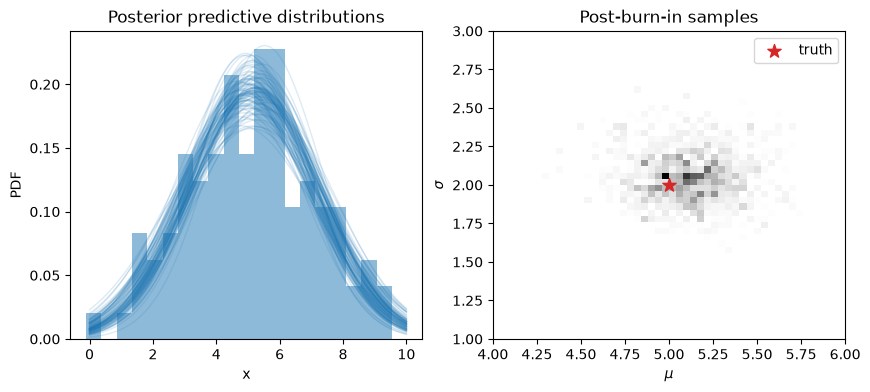

In [17]:
posterior_chain = post_burn_in_chains.reshape(-1,2)
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].hist(data, bins=20, alpha=0.5, density=True, label='data')
draws = np.random.choice(len(posterior_chain), size=100, replace=False)
for mean, std in posterior_chain[draws]:
    axs[0].plot(xs, norm_pdf(xs, mean, std),
                lw=1, alpha=0.15, color='tab:blue')
axs[0].set_xlabel('x')
axs[0].set_ylabel('PDF')
axs[0].set_title('Posterior predictive distributions')

axs[1].hist2d(posterior_chain[:, 0], posterior_chain[:, 1],
              range=((mean_min, mean_max), (std_min, std_max)),
              bins=50, density=True, cmap='Greys')
axs[1].scatter(mean_real, std_real, marker='*', color='tab:red',
               s=100, label='truth')
axs[1].set_xlabel(r'$\mu$')
axs[1].set_ylabel(r'$\sigma$')
axs[1].set_title('Post-burn-in samples')
axs[1].legend();